**Modeling IL2RA Gene Regulation and Lupus Risk through Transformer-Based Analysis**

Samarpita Patra

Task 1. TF Binding Prediction using the DNABERT-2 Transformer 
Employing ChIP-seq Signals and In Silico Mutation to Quantify Binding Classification


Methodology
1. Generate a dataset of binding and nonbinding DNA sequences on Chromosome 10 by looking at ChIP-seq data from relevant transcription factors (TF) in the IL2RA gene region
2. Use supervised learning to train a classifier that employs DNABERT-2 to extract embeddings that inform the linear classification head to binding values. The model learns the functional relationship between DNA sequence and TF Binding classification.
3. Compared Logistic Regression and SVM to quantify the best training classifier for binding prediction. 
4. Validation through Variant Analysis: Obtained Sequences of Known Pathogenic Variants Linked to SLE and analyzed the wild type sequence and mutant sequence through three different comparisons: 
5. Generated Pair embeddings from DNABERT-2 of wild type and mutant sequence. Used Cosine Similarity between paired embeddings to categorize if certain mutations have high impact. 
6. Calculate Risk Score by comparing binding prediction probabilities generated by IL2RA Binding Classifier of paired sequences
7. Use Position Weighted Matrices of relevant Transcription Factors to score both wild type and mutant sequences. Calculate the delta between two scores to measure the change in binding affinity of a transcription factor (TF) 


Command to download encode data: !cat files_rela.txt | xargs -n 1 curl -O -L

In [1]:
from huggingface_hub import login
#from google.colab import userdata
#hf_token = userdata.get('HF_TOKEN')
#login(hf_token)

/Users/samarpitapatra/cs690u/final_project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from transformers import AutoTokenizer, AutoModel
from transformers.models.bert.configuration_bert import BertConfig

from Bio import motifs
from pyfaidx import Fasta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.functional import cosine_similarity

from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

In [3]:
import plotting

SANITY CHECK:

original model loading was not working
https://huggingface.co/zhihan1996/DNABERT-2-117M
```
# tokenizer = AutoTokenizer.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)
model = AutoModel.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)

dna = "ACGTAGCATCGGATCTATCTATCGACACTTGGTTATCGATCTACGAGCATCTCGTTAGC"
inputs = tokenizer(dna, return_tensors = 'pt')["input_ids"]
hidden_states = model(inputs)[0] # [1, sequence_length, 768]

embedding with mean pooling
embedding_mean = torch.mean(hidden_states[0], dim=0)
print(embedding_mean.shape) # expect to be 768

embedding with max pooling
embedding_max = torch.max(hidden_states[0], dim=0)[0]
print(embedding_max.shape) # expect to be 768

```
Was able to find an equivalent model fixed by community member:
https://huggingface.co/quietflamingo/dnabert2-no-flashattention



In [ ]:
#SANITY CHECK DNABERT-2 MODEL loading

print("=" * 60)
print("DNABERT-2 Model Testing")
print("=" * 60)

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✓ Device: {device}")

# Load model
print("\nLoading DNABERT-2...")
tokenizer = AutoTokenizer.from_pretrained(
    "quietflamingo/dnabert2-fixed",
    trust_remote_code=True
)

config = BertConfig.from_pretrained("quietflamingo/dnabert2-fixed")
model = AutoModel.from_pretrained("quietflamingo/dnabert2-fixed", config=config)
model = model.to(device)

if torch.cuda.is_available():
    model = model.half()

print(f"✓ Model loaded on: {device}")


In [ ]:
### VERIFY model can generate embeddings

dna = "ACGTAGCATCGGATCTATCTATCGACACTTGGTTATCGATCTACGAGCATCTCGTTAGC"
# Tokenize - this returns a dictionary
inputs = tokenizer(dna, return_tensors='pt', padding=True, truncation=True)

# Check what inputs contains
print(f"Input keys: {inputs.keys()}")
print(f"Input IDs shape: {inputs['input_ids'].shape}")

# Move to device
inputs = {k: v.to(device) for k, v in inputs.items()}

hidden_states = model(**inputs)[0] # [1, sequence_length, 768]

# embedding with mean pooling
embedding_mean = torch.mean(hidden_states[0], dim=0)
print(embedding_mean.shape) # expect to be 768

# embedding with max pooling
embedding_max = torch.max(hidden_states[0], dim=0)[0]
print(embedding_max.shape) # expect to be 768

Load genomic sequencing data from Chromosome 10 (where IL2RA gene is located)
Exact position is 10:6010689-6062370 #source: https://www.ncbi.nlm.nih.gov/gene/3559#genomic-context

In [ ]:
!mkdir -p genome
!wget -O genome/chr10.fa.gz https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr10.fa.gz
!gunzip genome/chr10.fa.gz

In [4]:
genome_chr10 = Fasta('/Users/samarpitapatra/cs690u/final_project/task1/data/genome/chr10.fa')
ilra_gene_coordinates = (6010689, 6062370) 

ChIP_seq data gives you:
  chr (chromosome number),
  start (start of tf binding on human genome seq),
  end (end of tf binding on human genome seq),
  score (scaled quality value, use data above score >= 700 ),
  signalValue (raw ChIP-seq enrichment),
  pValue (pValue == -log10(p-value)),
  qValue (qValue == -log10(q-value)),
  width (length of TF binding to calculate sequence segments)

In [13]:
def generate_allele_sequence_dataset_for_wt_gene(filepaths):

  wt_sequence_df = pd.DataFrame(columns=[
      'tf_name',
      'marker',
      'genome_range',
      'seq',
      'score',
      'signalValue',
      'is_binding'])

  all_pos_sequences = []
  all_neg_sequences = []

  for tf_name, filepath in filepaths.items():
    print(f"\nAnalyzing peaks of {tf_name}...")

    # Read peaks
    peaks = pd.read_csv(filepath, sep='\t', header=None)
    peaks.columns = ['chr', 'start', 'end', 'name', 'score', 'strand',
                    'signalValue', 'pValue', 'qValue', 'peak']
    peaks['width'] = peaks['end'] - peaks['start']

    peaks_chr10 = peaks[peaks['chr'] == 'chr10']

    # Print summary
    print(f"\n{'='*60}")
    print(f"{tf_name} in Chr10 ChIP-seq Summary")
    print(f"{'='*60}")
    print(f"Total peaks: {len(peaks_chr10):,}")
    print(f"Mean peak width: {peaks_chr10['width'].mean():.1f} bp")

    #visualize
    fig = plotting.visualize_peaks_simple(peaks_chr10, tf_name, save_prefix=f'data/plots/{tf_name}_chr10')
    plt.close()

    #Positive sequences that correlate to TF binding
    records = []
    window_size = 512 #to match DNABERT-2 max tokens

    for measured_peak in peaks_chr10.itertuples():

      window_start = measured_peak.start - 50
      window_end = window_start + window_size
      seq_obj = genome_chr10['chr10'][window_start:window_end]

      if measured_peak.score >= 700:
        records.append({
            'tf_name': tf_name,
            'marker': seq_obj.name,
            'genome_range': (window_start, window_end),
            'seq': str(seq_obj),
            'score': measured_peak.score,
            'signalValue': measured_peak.signalValue,
            'is_binding': 1
        })

    wt_sequences_pos = pd.DataFrame.from_records(records)
    all_pos_sequences.append(wt_sequences_pos)

    #Generate same amount of negative sequences that do not correlate to TF binding
    records_neg = []
    pos_seqs_ranges = pd.IntervalIndex.from_tuples(wt_sequences_pos['genome_range'])

    for i in range(len(wt_sequences_pos)):
      #To ensure it does not correlate to TF binding site regions
      found = False
      while not found:
        window_start = np.random.randint(0, len(genome_chr10['chr10']) - window_size)
        window_end = window_start + window_size
        current_window = pd.Interval(window_start, window_end)

        if not pos_seqs_ranges.overlaps(current_window).any():
          #add genomic sequences outside of tf binding regions
          seq_obj = genome_chr10['chr10'][window_start:window_end]
          records_neg.append({
            'tf_name': tf_name,
            'marker': seq_obj.name,
            'genome_range': (window_start, window_end),
            'seq': str(seq_obj),
            'score': 'NaN',
            'signalValue': None,
            'is_binding': 0 })

          found = True

    wt_sequences_neg = pd.DataFrame.from_records(records_neg)
    all_neg_sequences.append(wt_sequences_neg)


  wt_sequences_df = pd.concat(all_pos_sequences + all_neg_sequences, ignore_index=True)

  return wt_sequences_df

In [14]:
filepaths = {
    'ELF1': 'data/chip_seqs/ELF1_peaks.bed',
    'STAT5A': 'data/chip_seqs/STAT5A_peaks.bed',
    'STAT5B': 'data/chip_seqs/STAT5B_peaks.bed'
    }

sequence_datasets = generate_allele_sequence_dataset_for_wt_gene(filepaths)


Analyzing peaks of ELF1...

ELF1 in Chr10 ChIP-seq Summary
Total peaks: 1,576
Mean peak width: 394.7 bp
Saved to: data/plots/ELF1_chr10_simple.png

Analyzing peaks of STAT5A...

STAT5A in Chr10 ChIP-seq Summary
Total peaks: 342
Mean peak width: 589.7 bp
Saved to: data/plots/STAT5A_chr10_simple.png

Analyzing peaks of STAT5B...

STAT5B in Chr10 ChIP-seq Summary
Total peaks: 122
Mean peak width: 279.4 bp
Saved to: data/plots/STAT5B_chr10_simple.png


Data Exploration and Preparation for Classification: Visualize the sequence dataset to see if there is class imbalance, Verify that the sequences generated are all of the same length

✓ Saved to: data/plots/visualize_wt_sequences_simple.png


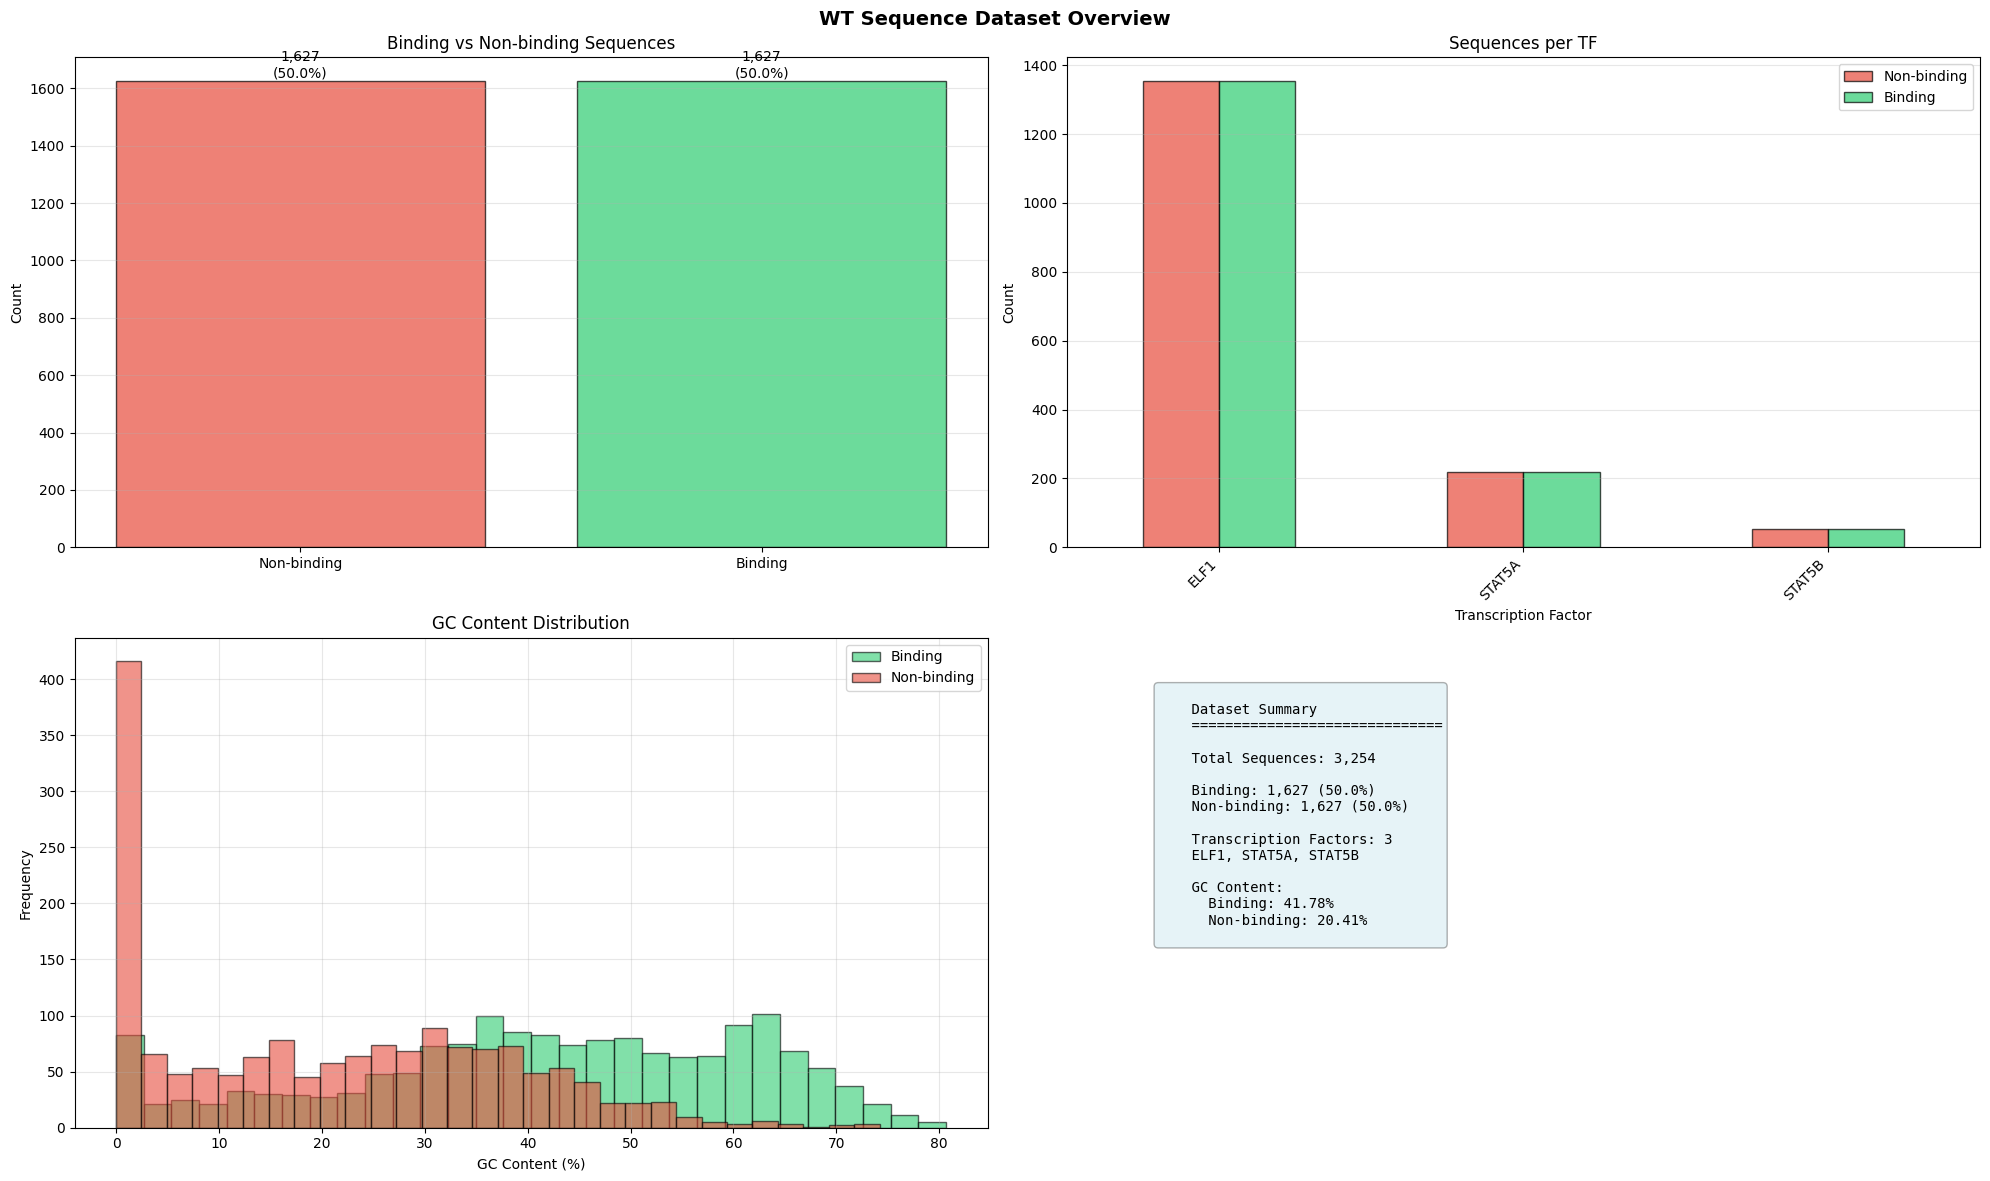

In [16]:
fig = plotting.visualize_sequence_dataset_simple(sequence_datasets, save_prefix= 'data/plots/visualize_wt_sequences')

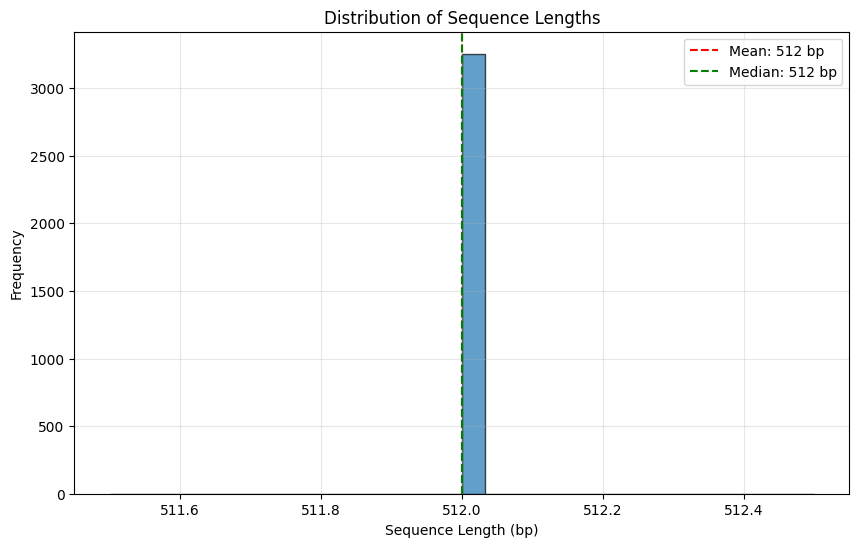

Saved: wildtype_sequence_lengths.png


In [17]:

fig = plotting.plot_sequence_lengths(sequence_datasets['seq'],'data/plots')

Tokenize Sequences according to DNABERT-2 input format

In [18]:
def load_dnabert2_model():
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  print(f"\n✓ Device: {device}")

  # Load model
  print("\nLoading DNABERT-2...")
  tokenizer = AutoTokenizer.from_pretrained(
      "quietflamingo/dnabert2-fixed",
      trust_remote_code=True
  )

  config = BertConfig.from_pretrained("quietflamingo/dnabert2-fixed")
  model = AutoModel.from_pretrained("quietflamingo/dnabert2-fixed", config=config)
  model = model.to(device)

  if torch.cuda.is_available():
      model = model.half()

  print(f"✓ Model loaded on: {device}")
  return model, tokenizer, device

In [19]:
dnabert_model, tokenizer, device = load_dnabert2_model()


✓ Device: cpu

Loading DNABERT-2...


Loading weights: 100%|██████████| 52/52 [00:00<00:00, 18239.15it/s]
[transformers] BertModel LOAD REPORT from: quietflamingo/dnabert2-fixed
Key                                                    | Status     | 
-------------------------------------------------------+------------+-
bert.encoder.layer.{0...11}.attention.self.Wqkv.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias                   | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.wo.weight              | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.wo.bias                | UNEXPECTED | 
bert.encoder.layer.{0...11}.attention.self.Wqkv.weight | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.gated_layers.weight    | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.layernorm.weight       | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.layernorm.bias         | UNEXPECTED | 
cls.predictions.decoder.weight                         | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight             | UNEXPECTED | 
cls.pred

✓ Model loaded on: cpu


In [21]:
#Tokenize sequences according to DNABERT-2 input format (k-mer tokenization)
def batch_tokenize(sequences, batch_size=32):
    all_input_ids = []
    all_attention_masks = []

    for i in range(0, len(sequences), batch_size):
        batch = sequences[i:i + batch_size]

        tokenized = tokenizer(
            batch,
            padding='max_length',
            truncation=True,
            max_length= 512,
            return_tensors="pt"
        )

        all_input_ids.append(tokenized['input_ids'])
        all_attention_masks.append(tokenized['attention_mask'])

    return {
        'input_ids': torch.cat(all_input_ids, dim=0),
        'attention_mask': torch.cat(all_attention_masks, dim=0),
    }

sequences = sequence_datasets['seq'].tolist()
tokenized = batch_tokenize(sequences, batch_size=32)

#Save
torch.save(tokenized, 'data/tokenized_chipseq_wt.pt')

# Load later
#tokenized = torch.load('tokenized.pt')


In [22]:
#easier to process data for training and evaluation if using pytorch dataset and dataloader
class DNASequenceDataset(Dataset):
    """
    PyTorch Dataset for DNA sequences and binding labels.
    """
    def __init__(self, sequences, labels, tokenizer, max_length=512):
        """
        Args:
            sequences: List of DNA sequences (strings)
            labels: List of labels (0 or 1)
            tokenizer: DNABERT-2 tokenizer
            max_length: Maximum sequence length
        """
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        """
        Returns a single training example.
        """
        sequence = self.sequences[idx]
        label = self.labels[idx]

        # Tokenize the sequence
        encoding = self.tokenizer(
            sequence,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),      # (seq_len,)
            'attention_mask': encoding['attention_mask'].squeeze(0),  # (seq_len,)
            'label': torch.tensor(label, dtype=torch.long)      # scalar
        }


Model Development: Compared Logisitic Regression and SVM Heads 

In [23]:
class IL2RABindingClassifier_LR(nn.Module):
    """
    Binary classifier for TF binding prediction using DNABERT-2 + Logistic Regression.

    Architecture:
    - DNABERT-2 (frozen): Extracts 768-dim embeddings
    - Logistic Regression (sklearn): Classifies embeddings into binding/no-binding
    """

    def __init__(self, dnabert_model, dropout_rate=0.1):
        """
        Args:
            dnabert_model: Pre-trained DNABERT-2 model
            dropout_rate: Dropout rate for regularization
        """
        super(IL2RABindingClassifier_LR, self).__init__()

        self.dnabert = dnabert_model
        self.dropout = nn.Dropout(dropout_rate)

        # Logistic Regression classifier (sklearn)
        self.lr = None
        self.lr_trained = False

        # Freeze DNABERT-2
        for param in self.dnabert.parameters():
            param.requires_grad = False

    def extract_embeddings(self, input_ids, attention_mask):
        """
        Extract DNABERT-2 embeddings.

        Args:
            input_ids: Token IDs (batch_size, seq_len)
            attention_mask: Attention mask (batch_size, seq_len)

        Returns:
            embeddings: (batch_size, 768) numpy array
        """
        # Get DNABERT-2 output
        with torch.no_grad():
            outputs = self.dnabert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            cls_embedding = outputs.last_hidden_state[:, 0, :]  # (batch_size, 768)

        # Apply dropout
        cls_embedding = self.dropout(cls_embedding)

        # Convert to numpy for sklearn
        embeddings = cls_embedding.cpu().detach().numpy()

        return embeddings

    def forward(self, input_ids, attention_mask):
        """
        Forward pass through DNABERT-2 + Logistic Regression.

        Args:
            input_ids: Token IDs (batch_size, seq_len)
            attention_mask: Attention mask (batch_size, seq_len)

        Returns:
            predictions: (batch_size,) tensor of class predictions
            probabilities: (batch_size, 2) tensor of class probabilities
        """
        # Extract embeddings
        embeddings = self.extract_embeddings(input_ids, attention_mask)

        # Check if LR is trained
        if self.lr is None or not self.lr_trained:
            raise RuntimeError(
                "Logistic Regression classifier not trained yet! "
                "Call train_classifier() first."
            )

        # Predict with Logistic Regression
        predictions = self.lr.predict(embeddings)
        probabilities = self.lr.predict_proba(embeddings)

        # Convert back to PyTorch tensors
        predictions = torch.tensor(predictions, dtype=torch.long)
        probabilities = torch.tensor(probabilities, dtype=torch.float32)

        return predictions, probabilities

    def fit (self, train_loader, device, lr_params=None):
        """
        Train the Logistic Regression classifier on extracted embeddings.

        Args:
            train_loader: PyTorch DataLoader with training data
            device: torch.device (cuda/cpu)
            lr_params: dict of Logistic Regression hyperparameters

        Returns:
            Trained LogisticRegression classifier
        """
        print("\nTraining on LR classifier set...")

        # Extract all embeddings and labels
        all_embeddings = []
        all_labels = []

        self.eval()  # Set to eval mode

        for batch_idx, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label']

            # Extract embeddings
            embeddings = self.extract_embeddings(input_ids, attention_mask)

            all_embeddings.append(embeddings)
            all_labels.append(labels.numpy())

            if (batch_idx + 1) % 10 == 0:
                print(f"   Processed {batch_idx + 1}/{len(train_loader)} batches")

        # Concatenate all batches
        X_train = np.vstack(all_embeddings)  # (N, 768)
        y_train = np.concatenate(all_labels)  # (N,)


        # Set default Logistic Regression parameters
        if lr_params is None:
            lr_params = {
                'C': 1.0,                    # Regularization strength
                'penalty': 'l2',              # L2 regularization
                'solver': 'lbfgs',            # Optimization algorithm
                'max_iter': 1000,             # Maximum iterations
                'class_weight': 'balanced',   # Handle class imbalance
                'random_state': 42,
            }


        # Create and train Logistic Regression
        self.lr = LogisticRegression(**lr_params)
        self.lr.fit(X_train, y_train)
        self.lr_trained = True

        # Evaluate on training set
        train_predictions = self.lr.predict(X_train)
        train_accuracy = np.mean(train_predictions == y_train)
        train_f1 = f1_score(y_train, train_predictions)

        print(f"\n4. Training Results:")
        print(f"Training Accuracy: {train_accuracy:.4f}")
        print(f"Training F1-score: {train_f1:.4f}")

        return self.lr

    def evaluate(self, val_loader, device):
        """
        Evaluate the classifier on validation/test data.

        Args:
            val_loader: PyTorch DataLoader with validation data
            device: torch.device (cuda/cpu)

        Returns:
            metrics: Dictionary of evaluation metrics
        """
        print("\nEvaluating on validation set...")

        # Extract embeddings and labels
        all_embeddings = []
        all_labels = []

        self.eval()

        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label']

            embeddings = self.extract_embeddings(input_ids, attention_mask)

            all_embeddings.append(embeddings)
            all_labels.append(labels.numpy())

        X_val = np.vstack(all_embeddings)
        y_val = np.concatenate(all_labels)

        # Predict
        predictions = self.lr.predict(X_val)
        probabilities = self.lr.predict_proba(X_val)

        # Calculate metrics
        metrics = {
            'accuracy': accuracy_score(y_val, predictions),
            'f1': f1_score(y_val, predictions),
            'roc_auc': roc_auc_score(y_val, probabilities[:, 1]),
            'confusion_matrix': confusion_matrix(y_val, predictions),
            'predictions': predictions,
            'probabilities': probabilities,
            'true_labels': y_val
        }

        print(f"\nValidation Accuracy: {metrics['accuracy']:.4f}")
        print(f"Validation F1-score: {metrics['f1']:.4f}")
        print(f"ROC AUC: {metrics['roc_auc']:.4f}")

        print("\nConfusion Matrix:")
        print(metrics['confusion_matrix'])

        return metrics

In [24]:
class IL2RABindingClassifier_SVM(nn.Module):

    """
    Two-stage classifier:
    1. DNABERT-2 for embedding extraction
    2. SVM for classification
    """
    def __init__(self, dnabert_model, tokenizer, device, dropout_rate=0.1):

        super(IL2RABindingClassifier_SVM, self).__init__()

        self.dnabert = dnabert_model
        self.tokenizer = tokenizer
        self.device = device
        self.svm = None
        self.svm_trained = False
        self.dropout = nn.Dropout(dropout_rate)

        # Freeze DNABERT-2
        for param in self.dnabert.parameters():
          param.requires_grad = False

        self.dnabert.eval()

    def extract_embeddings(self, input_ids, attention_mask):
        """
        Extract DNABERT-2 embeddings.

        Args:
            input_ids: Token IDs (batch_size, seq_len)
            attention_mask: Attention mask (batch_size, seq_len)

        Returns:
            embeddings: (batch_size, 768) numpy array
        """
        # Get DNABERT-2 output
        with torch.no_grad():
            outputs = self.dnabert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            cls_embedding = outputs.last_hidden_state[:, 0, :]  # (batch_size, 768)

        # Apply dropout
        cls_embedding = self.dropout(cls_embedding)

        # Convert to numpy for sklearn
        embeddings = cls_embedding.cpu().detach().numpy()

        return embeddings


    def fit(self, train_loader, device, svm_params=None):
          """
          Train the SVM classifier.

          Args:
          train_sequences: List of training DNA sequences
          train_labels: List of training labels (0 or 1)
          """
          print("\nTraining on SVM classifier set...")

          # Extract all embeddings and labels
          all_embeddings = []
          all_labels = []

          self.eval()  # Set to eval mode

          for batch_idx, batch in enumerate(train_loader):
              input_ids = batch['input_ids'].to(device)
              attention_mask = batch['attention_mask'].to(device)
              labels = batch['label']

              # Extract embeddings
              embeddings = self.extract_embeddings(input_ids, attention_mask)

              all_embeddings.append(embeddings)
              all_labels.append(labels.numpy())

              if (batch_idx + 1) % 10 == 0:
                  print(f"   Processed {batch_idx + 1}/{len(train_loader)} batches")

          # Concatenate all batches
          X_train = np.vstack(all_embeddings)  # (N, 768)
          y_train = np.concatenate(all_labels)  # (N,)

          if svm_params is None:
              svm_params = {
                  'C': 1.0,
                  'kernel': 'rbf',
                  'probability': True,
                  'random_state': 42
              }

          self.svm = SVC(**svm_params)
          self.svm.fit(X_train, y_train)
          self.svm_trained = True

          # Evaluate on training set
          train_predictions = self.svm.predict(X_train)
          train_accuracy = np.mean(train_predictions == y_train)
          train_f1 = f1_score(y_train, train_predictions)

          print(f"\n4. Training Results:")
          print(f"Training Accuracy: {train_accuracy:.4f}")
          print(f"Training F1-score: {train_f1:.4f}")

          return self.svm

    def evaluate(self, val_loader, device):
          """
          Evaluate the classifier on validation/test data.

          Args:
              val_loader: PyTorch DataLoader with validation data
              device: torch.device (cuda/cpu)

          Returns:
              metrics: Dictionary of evaluation metrics
          """
          print("\nEvaluating on validation set...")

          # Extract embeddings and labels
          all_embeddings = []
          all_labels = []

          self.eval()

          for batch in val_loader:
              input_ids = batch['input_ids'].to(device)
              attention_mask = batch['attention_mask'].to(device)
              labels = batch['label']

              embeddings = self.extract_embeddings(input_ids, attention_mask)

              all_embeddings.append(embeddings)
              all_labels.append(labels.numpy())

          X_val = np.vstack(all_embeddings)
          y_val = np.concatenate(all_labels)

          # Predict
          predictions = self.svm.predict(X_val)
          probabilities = self.svm.predict_proba(X_val)

          # Calculate metrics
          metrics = {
              'accuracy': accuracy_score(y_val, predictions),
              'f1': f1_score(y_val, predictions),
              'roc_auc': roc_auc_score(y_val, probabilities[:, 1]),
              'confusion_matrix': confusion_matrix(y_val, predictions),
              'predictions': predictions,
              'probabilities': probabilities,
              'true_labels': y_val
          }

          print(f"\nValidation Accuracy: {metrics['accuracy']:.4f}")
          print(f"Validation F1-score: {metrics['f1']:.4f}")
          print(f"ROC AUC: {metrics['roc_auc']:.4f}")

          print("\nConfusion Matrix:")
          print(metrics['confusion_matrix'])

          return metrics


    def forward (self, input_ids, attention_mask):
          """
          Forward pass through DNABERT-2 + SVM.

          Args:
              input_ids: Token IDs (batch_size, seq_len)
              attention_mask: Attention mask (batch_size, seq_len)

          Returns:
              predictions: (batch_size,) tensor of class predictions
              probabilities: (batch_size, 2) tensor of class probabilities
          """
          # Extract embeddings
          embeddings = self.extract_embeddings(input_ids, attention_mask)

          # Check if LR is trained
          if self.svm is None or not self.svm_trained:
              raise RuntimeError(
                  "SVM classifier not trained yet! "
                  "Call train() first."
              )

          # Predict with Logistic Regression
          predictions = self.svm.predict(embeddings)
          probabilities = self.svm.predict_proba(embeddings)

          # Convert back to PyTorch tensors
          predictions = torch.tensor(predictions, dtype=torch.long)
          probabilities = torch.tensor(probabilities, dtype=torch.float32)

          return predictions, probabilities

Training Models and Assessing Each Using Stratified KFold Cross Validation

Use Stratified K-Fold to Assess IL2RAClassifier_LR()

In [26]:
dnabert_model, tokenizer, device = load_dnabert2_model()

X = sequence_datasets['seq'].tolist()
y = sequence_datasets['is_binding'].tolist()

# Convert to numpy arrays (scikit-learn handles arrays better for indexing)
X = np.array(X)
y = np.array(y)

#metrics
all_metrics = {}

# 1. Initialize the StratifiedKFold object
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Loop through the folds
for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
  print(f"--- Training Fold {fold+1} ---")

  # Create the train/val sets for this fold
  X_train, X_val = X[train_index], X[val_index]
  y_train, y_val = y[train_index], y[val_index]

  lr_model = IL2RABindingClassifier_LR(dnabert_model, dropout_rate=0.1)

  lr_model = lr_model.to(device)

  train_sequences = list(X_train)
  train_labels = list(y_train)
  val_sequences = list(X_val)
  val_labels = list(y_val)

  train_dataset = DNASequenceDataset(train_sequences, train_labels, tokenizer)
  val_dataset = DNASequenceDataset(val_sequences, val_labels, tokenizer)

  # Create dataloaders
  train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
  val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

  lr_model.fit(train_loader, device)
  metrics = lr_model.evaluate(val_loader, device)
  all_metrics[fold] = metrics

all_metrics_lr_df = pd.DataFrame(all_metrics).T
# print(f"\nAverage Validation Accuracy: {float(all_metrics_lr_df['accuracy'].mean()):.4f}")
# print(f"Average Validation F1-score: {float(all_metrics_lr_df['f1'].mean()):.4f}")
# print(f"Average ROC AUC: {float(all_metrics_lr_df['roc_auc'].mean()):.4f}")
table = plotting.print_metrics_table(all_metrics_lr_df)



✓ Device: cpu

Loading DNABERT-2...


Loading weights: 100%|██████████| 52/52 [00:00<00:00, 36594.60it/s]
[transformers] BertModel LOAD REPORT from: quietflamingo/dnabert2-fixed
Key                                                    | Status     | 
-------------------------------------------------------+------------+-
bert.encoder.layer.{0...11}.attention.self.Wqkv.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias                   | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.wo.weight              | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.wo.bias                | UNEXPECTED | 
bert.encoder.layer.{0...11}.attention.self.Wqkv.weight | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.gated_layers.weight    | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.layernorm.weight       | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.layernorm.bias         | UNEXPECTED | 
cls.predictions.decoder.weight                         | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight             | UNEXPECTED | 
cls.pred

✓ Model loaded on: cpu
--- Training Fold 1 ---

Training on LR classifier set...
   Processed 10/326 batches
   Processed 20/326 batches
   Processed 30/326 batches
   Processed 40/326 batches
   Processed 50/326 batches
   Processed 60/326 batches
   Processed 70/326 batches
   Processed 80/326 batches
   Processed 90/326 batches
   Processed 100/326 batches
   Processed 110/326 batches
   Processed 120/326 batches
   Processed 130/326 batches
   Processed 140/326 batches
   Processed 150/326 batches
   Processed 160/326 batches
   Processed 170/326 batches
   Processed 180/326 batches
   Processed 190/326 batches
   Processed 200/326 batches
   Processed 210/326 batches
   Processed 220/326 batches
   Processed 230/326 batches
   Processed 240/326 batches
   Processed 250/326 batches
   Processed 260/326 batches
   Processed 270/326 batches
   Processed 280/326 batches
   Processed 290/326 batches
   Processed 300/326 batches
   Processed 310/326 batches
   Processed 320/326 batches


/Users/samarpitapatra/cs690u/final_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



4. Training Results:
Training Accuracy: 0.7376
Training F1-score: 0.7124

Evaluating on validation set...

Validation Accuracy: 0.7389
Validation F1-score: 0.7157
ROC AUC: 0.8129

Confusion Matrix:
[[267  58]
 [112 214]]
--- Training Fold 2 ---

Training on LR classifier set...
   Processed 10/326 batches
   Processed 20/326 batches
   Processed 30/326 batches
   Processed 40/326 batches
   Processed 50/326 batches
   Processed 60/326 batches
   Processed 70/326 batches
   Processed 80/326 batches
   Processed 90/326 batches
   Processed 100/326 batches
   Processed 110/326 batches
   Processed 120/326 batches
   Processed 130/326 batches
   Processed 140/326 batches
   Processed 150/326 batches
   Processed 160/326 batches
   Processed 170/326 batches
   Processed 180/326 batches
   Processed 190/326 batches
   Processed 200/326 batches
   Processed 210/326 batches
   Processed 220/326 batches
   Processed 230/326 batches
   Processed 240/326 batches
   Processed 250/326 batches
   P

...


4. Training Results:
Training Accuracy: 0.7353
Training F1-score: 0.7104

Evaluating on validation set...

Validation Accuracy: 0.7281
Validation F1-score: 0.6985
ROC AUC: 0.8014

Confusion Matrix:
[[269  57]
 [120 205]]
--- Training Fold 4 ---

Training on LR classifier set...
   Processed 10/326 batches
   Processed 20/326 batches
   Processed 30/326 batches
   Processed 40/326 batches
   Processed 50/326 batches
   Processed 60/326 batches
   Processed 70/326 batches
   Processed 80/326 batches
   Processed 90/326 batches
   Processed 100/326 batches
   Processed 110/326 batches
   Processed 120/326 batches
   Processed 130/326 batches
   Processed 140/326 batches
   Processed 150/326 batches
   Processed 160/326 batches
   Processed 170/326 batches
   Processed 180/326 batches
   Processed 190/326 batches
   Processed 200/326 batches
   Processed 210/326 batches
   Processed 220/326 batches
   Processed 230/326 batches
   Processed 240/326 batches
   Processed 250/326 batches
   P

/Users/samarpitapatra/cs690u/final_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



4. Training Results:
Training Accuracy: 0.7407
Training F1-score: 0.7167

Evaluating on validation set...

Validation Accuracy: 0.7204
Validation F1-score: 0.6997
ROC AUC: 0.7879

Confusion Matrix:
[[257  69]
 [113 212]]
--- Training Fold 5 ---

Training on LR classifier set...
   Processed 10/326 batches
   Processed 20/326 batches
   Processed 30/326 batches
   Processed 40/326 batches
   Processed 50/326 batches
   Processed 60/326 batches
   Processed 70/326 batches
   Processed 80/326 batches
   Processed 90/326 batches
   Processed 100/326 batches
   Processed 110/326 batches
   Processed 120/326 batches
   Processed 130/326 batches
   Processed 140/326 batches
   Processed 150/326 batches
   Processed 160/326 batches
   Processed 170/326 batches
   Processed 180/326 batches
   Processed 190/326 batches
   Processed 200/326 batches
   Processed 210/326 batches
   Processed 220/326 batches
   Processed 230/326 batches
   Processed 240/326 batches
   Processed 250/326 batches
   P

/Users/samarpitapatra/cs690u/final_project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



4. Training Results:
Training Accuracy: 0.7404
Training F1-score: 0.7176

Evaluating on validation set...

Validation Accuracy: 0.7123
Validation F1-score: 0.6847
ROC AUC: 0.7794

Confusion Matrix:
[[260  65]
 [122 203]]

VALIDATION METRICS SUMMARY
Metric               Mean            Std Dev         Range               
----------------------------------------------------------------------
Accuracy             0.7219          0.0119          0.7097 - 0.7389
F1-Score             0.6949          0.0153          0.6758 - 0.7157
ROC AUC              0.7979          0.0139          0.7794 - 0.8129


In [ ]:
torch.save(lr_model.state_dict(), 'best_model_logreg.pth')

Compare to ILRA svm model

In [27]:
dnabert_model, tokenizer, device = load_dnabert2_model()

X = sequence_datasets['seq'].tolist()
y = sequence_datasets['is_binding'].tolist()

# Convert to numpy arrays (scikit-learn handles arrays better for indexing)
X = np.array(X)
y = np.array(y)

#metrics
all_metrics = {}

# 1. Initialize the StratifiedKFold object
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Loop through the folds
for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
  print(f"--- Training Fold {fold+1} ---")

  # Create the train/val sets for this fold
  X_train, X_val = X[train_index], X[val_index]
  y_train, y_val = y[train_index], y[val_index]

  svm_model = IL2RABindingClassifier_SVM(dnabert_model, tokenizer, device)

  svm_model = svm_model.to(device)

  train_sequences = list(X_train)
  train_labels = list(y_train)
  val_sequences = list(X_val)
  val_labels = list(y_val)

  train_dataset = DNASequenceDataset(train_sequences, train_labels, tokenizer)
  val_dataset = DNASequenceDataset(val_sequences, val_labels, tokenizer)

  # Create dataloaders
  train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
  val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

  svm_model.fit(train_loader, device)
  metrics = svm_model.evaluate(val_loader, device)
  all_metrics[fold] = metrics

all_metrics_svm_df = pd.DataFrame(all_metrics).T
# print(f"\nAverage Validation Accuracy: {float(all_metrics_df['accuracy'].mean()):.4f}")
# print(f"Average Validation F1-score: {float(all_metrics_df['f1'].mean()):.4f}")
# print(f"Average ROC AUC: {float(all_metrics_df['roc_auc'].mean()):.4f}")
table = plotting.print_metrics_table(all_metrics_svm_df)


✓ Device: cpu

Loading DNABERT-2...


Loading weights: 100%|██████████| 52/52 [00:00<00:00, 38919.31it/s]
[transformers] BertModel LOAD REPORT from: quietflamingo/dnabert2-fixed
Key                                                    | Status     | 
-------------------------------------------------------+------------+-
bert.encoder.layer.{0...11}.attention.self.Wqkv.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias                   | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.wo.weight              | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.wo.bias                | UNEXPECTED | 
bert.encoder.layer.{0...11}.attention.self.Wqkv.weight | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.gated_layers.weight    | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.layernorm.weight       | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.layernorm.bias         | UNEXPECTED | 
cls.predictions.decoder.weight                         | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight             | UNEXPECTED | 
cls.pred

✓ Model loaded on: cpu
--- Training Fold 1 ---

Training on SVM classifier set...
   Processed 10/326 batches
   Processed 20/326 batches
   Processed 30/326 batches
   Processed 40/326 batches
   Processed 50/326 batches
   Processed 60/326 batches
   Processed 70/326 batches
   Processed 80/326 batches
   Processed 90/326 batches
   Processed 100/326 batches
   Processed 110/326 batches
   Processed 120/326 batches
   Processed 130/326 batches
   Processed 140/326 batches
   Processed 150/326 batches
   Processed 160/326 batches
   Processed 170/326 batches
   Processed 180/326 batches
   Processed 190/326 batches
   Processed 200/326 batches
   Processed 210/326 batches
   Processed 220/326 batches
   Processed 230/326 batches
   Processed 240/326 batches
   Processed 250/326 batches
   Processed 260/326 batches
   Processed 270/326 batches
   Processed 280/326 batches
   Processed 290/326 batches
   Processed 300/326 batches
   Processed 310/326 batches
   Processed 320/326 batches

In [ ]:
torch.save(svm_model.state_dict(), 'best_model_svm.pth')

In [ ]:
#dnabert_model, dropout_rate=0.1 #FOR LR
dnabert_model, tokenizer, device = load_dnabert2_model()
lr_model_uploaded = IL2RABindingClassifier_LR(dnabert_model, dropout_rate=0.1)
lr_model_uploaded.load_state_dict(torch.load('/content/best_model_logreg.pth'))

lr_model_uploaded.eval()

# Move to device if needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr_model_uploaded.to(device)

#why does this need training ?

Variant Analysis

In [29]:
#finding gene variants that correlate to SLE

#farh et al (not specifically linked to SLE)
#variant rs706779 #https://www.ncbi.nlm.nih.gov/snp/rs706779
#variant rs2104286 #https://www.ncbi.nlm.nih.gov/snp/rs2104286

#rs10795763 #https://www.ncbi.nlm.nih.gov/snp/rs10795763

#lit review: https://pmc.ncbi.nlm.nih.gov/articles/PMC2662820/
#variant rs11594656 #https://genopedia.com/variant/11594656 #https://www.ncbi.nlm.nih.gov/clinvar/RCV000015782/

#lit review: https://journals.plos.org/plosgenetics/article?id=10.1371/journal.pgen.1002406#pgen.1002406-Gregersen1
# variant Rs11101442 (pos 49.606 Mb) specifically on chr10  #https://www.ebi.ac.uk/gwas/variants/rs11101442

lupus_variants = {
    'rs11594656': {'ref': 'T', 'alternate': ['A'], 'pos': 6080046},
    'rs11101442': {'ref': 'C', 'alternate': ['A', 'T'], 'pos': 48728291},
    'rs706779': {'ref': 'T', 'alternate': ['A','C','G'], 'pos': 6056861},
    'rs2104286': {'ref': 'T', 'alternate': ['A', 'C', 'G'], 'pos': 6057082}
    }

Look at Variant to Analyze and Predict Using Model

In [36]:
#adding common variants in IL2RA region
#https://gnomad.broadinstitute.org/gene/ENSG00000134460?dataset=gnomad_r4

gnomAD_vcf_df = pd.read_csv("data/genome/gnomAD_v4.1.1_ENSG00000134460_2026_05_05_21_20_08.csv")
gnomAD_vcf_df = gnomAD_vcf_df[gnomAD_vcf_df['Flags'] != 'lof_flag']
gnomAD_risky_df = gnomAD_vcf_df[gnomAD_vcf_df['ClinVar Germline Classification'].isin(['Pathogenic', 'Likely pathogenic'])]
gnomAD_healthy_df = gnomAD_vcf_df[gnomAD_vcf_df['ClinVar Germline Classification'].isin(['Likely benign', 'Benign/Likely benign', 'Benign'])]

In [37]:
for index, row in gnomAD_risky_df.iterrows():

  il2ra_ranges = pd.IntervalIndex.from_tuples([ilra_gene_coordinates])
  
  if il2ra_ranges.contains(row['Position']): 
    continue 

  metadata = {
      'ref': row['Reference'],
      'alternate': row['Alternate'],
      'pos': row['Position']
  }

  lupus_variants[row['rsIDs']] = metadata


variant_sequences = {}

#pull sequence for wt and mutant
for variant_id, metadata in lupus_variants.items():
  pos = metadata['pos']
  window_start = pos - 256
  window_end = pos + 256

  genome_chr10seq_obj = genome_chr10['chr10'][window_start:window_end]
  wt_seq = str(genome_chr10seq_obj.seq)

  for alt in metadata['alternate']:
    mutant_seq = str(genome_chr10['chr10'][window_start:pos].seq) + alt + str(genome_chr10['chr10'][pos+1:window_end].seq)
    variant_sequences[variant_id+"_"+alt] = {'wt': wt_seq, 'mutant': mutant_seq}


✓ Saved to: data/plots/lupus_variants_simple.png


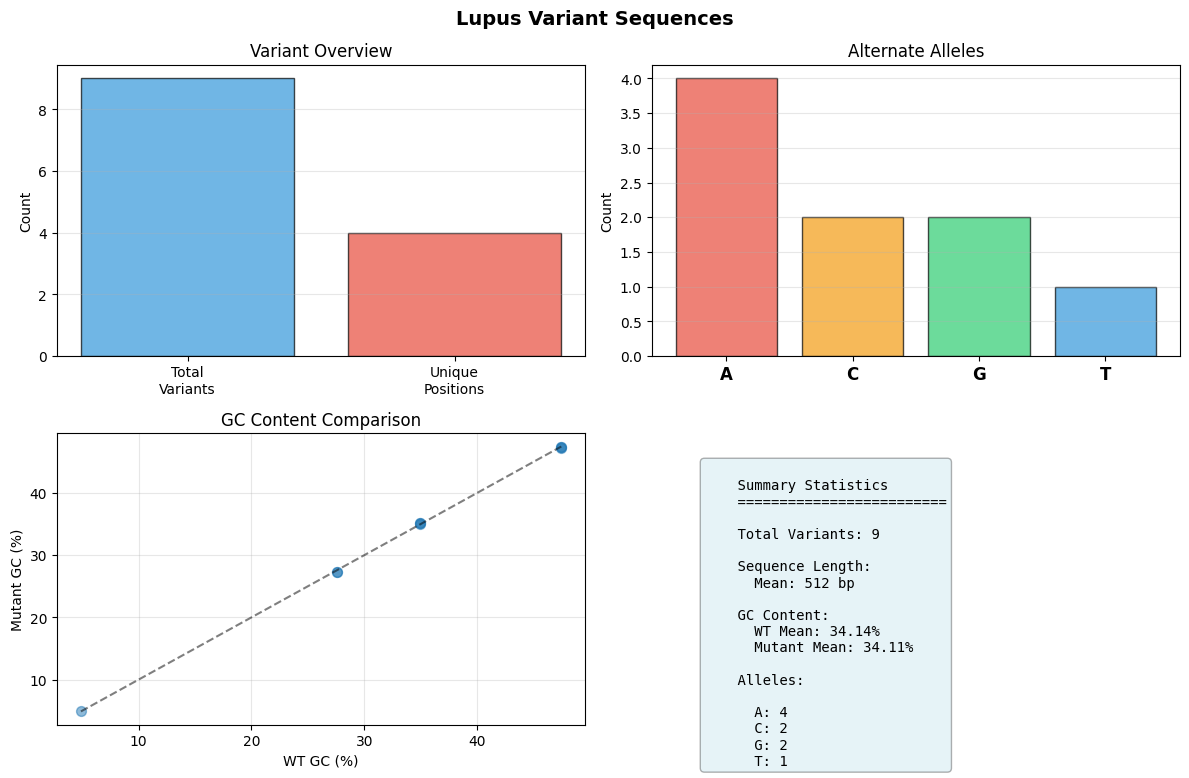

In [39]:
variant_sequences_df = pd.DataFrame(variant_sequences).T

plotting.visualize_variants_simple(variant_sequences_df, save_prefix='data/plots/lupus_variants')
plt.show()

In [40]:
dnabert_model, tokenizer, device = load_dnabert2_model()


✓ Device: cpu

Loading DNABERT-2...


Loading weights: 100%|██████████| 52/52 [00:00<00:00, 34260.73it/s]
[transformers] BertModel LOAD REPORT from: quietflamingo/dnabert2-fixed
Key                                                    | Status     | 
-------------------------------------------------------+------------+-
bert.encoder.layer.{0...11}.attention.self.Wqkv.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias                   | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.wo.weight              | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.wo.bias                | UNEXPECTED | 
bert.encoder.layer.{0...11}.attention.self.Wqkv.weight | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.gated_layers.weight    | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.layernorm.weight       | UNEXPECTED | 
bert.encoder.layer.{0...11}.mlp.layernorm.bias         | UNEXPECTED | 
cls.predictions.decoder.weight                         | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight             | UNEXPECTED | 
cls.pred

✓ Model loaded on: cpu


In [41]:
#iterate through variant sequences and calculate cosine similarity for each wt and variant pair
cosines= {}

for variant_id, sequences in variant_sequences.items():
  variant_seqs = list(sequences.values())
  variant_labels = list(sequences.keys())

  inputs_variant = tokenizer(
    variant_seqs,
    return_tensors='pt',
    padding=True,
    truncation=True)

  inputs_variant = {k: v.to(device) for k, v in inputs_variant.items()}

  with torch.no_grad():
    outputs_variant = dnabert_model(**inputs_variant)
    embeddings_variant = outputs_variant.last_hidden_state[:, 0, :]  # CLS tokens

  # Calculate cosine similarity
  #low cosine similarity is better ==> has a big effect
  cos_sim = cosine_similarity(embeddings_variant[0:1], embeddings_variant[1:2], dim=1)
  cosines[variant_id] = cos_sim.item()

  # print(f"Variant ID: {variant_id}")
  # print(f"Cosine Similarity: {cos_sim.item()}")


✓ Saved to: data/plots/lupus_variants_cosine_similarity_simple.png


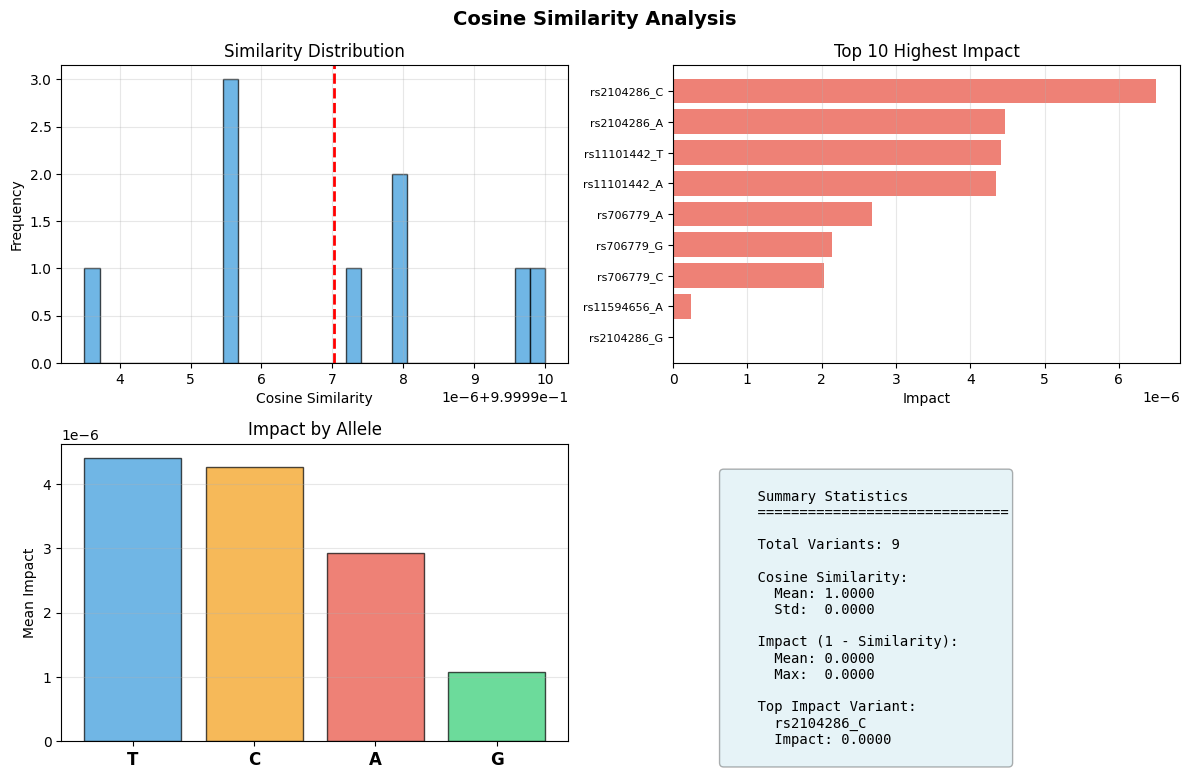

In [42]:
fig = plotting.visualize_cosines_simple(cosines, save_prefix='data/plots/lupus_variants_cosine_similarity')
plt.show()

Risk Scoring

In [43]:
lr_model.eval()
lr_model.to(device)

IL2RABindingClassifier_LR(
  (dnabert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(4096, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [44]:
risk_scores = {}

for variant_id, sequences in variant_sequences.items():
  variant_seqs = list(sequences.values())
  variant_labels = list(sequences.keys()) #['wt', 'mutant']

  inputs_variant = tokenizer(
    variant_seqs,
    return_tensors='pt',
    padding=True,
    truncation=True)

  inputs_variant = {k: v.to(device) for k, v in inputs_variant.items()}

  with torch.no_grad():
    predictions, probabilities = lr_model(inputs_variant['input_ids'],
                                       inputs_variant['attention_mask'])

  #calculate risk score
  #delta = P(binding|wt) - P(binding|mutant)
  delta = probabilities[0,1].item() - probabilities[1,1].item()
  # save risk score
  risk_scores[variant_id] = delta


Saved to: data/plots/lupus_variant_risk_scores_simple.png


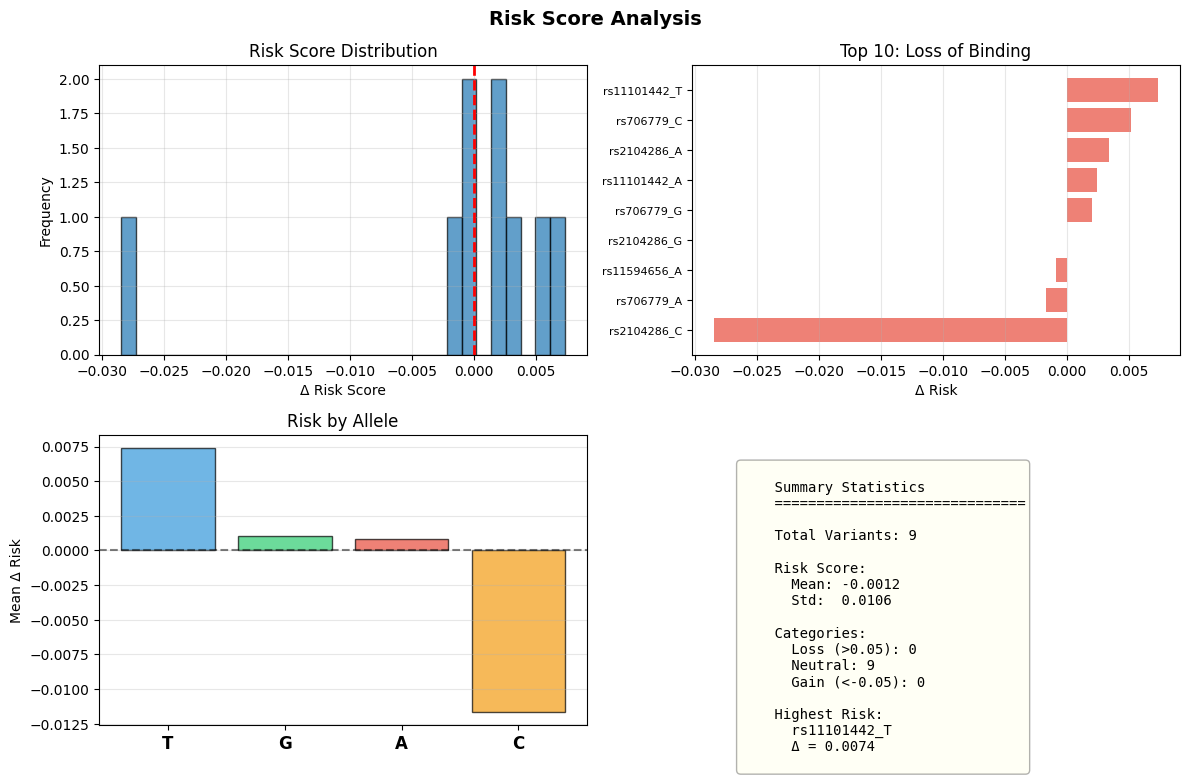

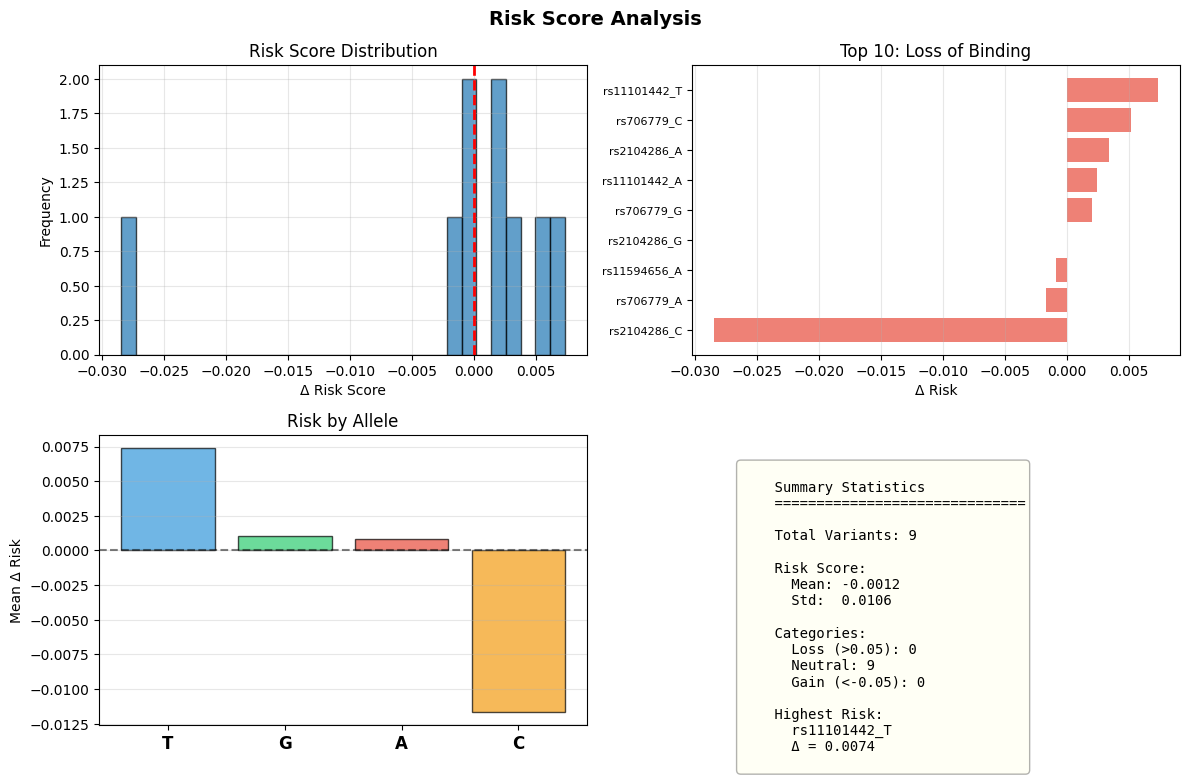

In [47]:
# plot risk scores
# Rank variants by predicted impact on TF binding

#positive score => alleles are risky
#negative score => alleles are not risky

plotting.visualize_risk_simple(risk_scores, save_prefix='data/plots/lupus_variant_risk_scores')

PWM-Based Validation
1. Implement PWM Scoring
2. ΔPWM = PWM(WT) - PWM(mutant) 
(Quantifies the difference in binding affinity scores between wt and variant seq)

Download PFM data and calculate PWM for STAT5A and STAT5B
Note: from Mouse dna, but [cite] mentioned the PWM for mouse and humans for STAT5A-B complex is pretty equivalent

In [49]:
filepath = "data/pfm_matrices/MA0519.1.jaspar"
with open(filepath) as handle:
  motif = motifs.read(handle, "jaspar")

stat5ab_pwm = motif.pwm

Download PFM data and calculate PWM for ELF1 TF

In [50]:
filepath = "data/pfm_matrices/MA0473.3.jaspar"
with open(filepath) as handle:
  motif = motifs.read(handle, "jaspar")

elf1_pwm = motif.pwm


In [51]:
def read_motif_scores(sequence, pwm):

    sequence = str(sequence).upper()
    motif_length = len(pwm)
    seq_length = len(sequence)

    scores = []

    # Slide PWM across sequence
    for i in range(seq_length - motif_length + 1):
        subseq = sequence[i:i + motif_length]
        score = 0

        for j, nucleotide in enumerate(subseq):
            if nucleotide in pwm[j]:
                score += pwm[j][nucleotide]

        scores.append(score)

    scores = np.array(scores) if scores else np.array([0])
    max_score = np.max(scores)
    max_pos = np.argmax(scores)

    return scores, max_score, max_pos

In [52]:
def categorize_impact(score_delta):
  if abs(score_delta) < 1:
    impact = "Minimal"
  elif abs(score_delta) < 2:
      impact = "Low"
  elif abs(score_delta) < 3:
      impact = "Moderate"
  elif abs(score_delta) < 5:
      impact = "High"
  else:
      impact = "Very High"

  return impact

In [53]:
pwm_scores = {}

for variant_id, sequences in variant_sequences.items():

  wt_seq = sequences['wt']
  mutant_seq = sequences['mutant']

  #for stat5ab
  wt_scores_5b, wt_max_score_5b, wt_max_pos_5b = read_motif_scores(wt_seq, stat5ab_pwm)
  mutant_scores_5b, mutant_max_score_5b, mutant_max_pos_5b = read_motif_scores(mutant_seq, stat5ab_pwm)

  delta_pwm_stat5ab = mutant_max_score_5b - wt_max_score_5b

  #for elf1
  wt_scores_e, wt_max_score_e, wt_max_pos_e = read_motif_scores(wt_seq, elf1_pwm)
  mutant_scores_e, mutant_max_score_e, mutant_max_pos_e = read_motif_scores(mutant_seq, elf1_pwm)

  delta_pwm_elf1 = mutant_max_score_e - wt_max_score_e

  pwm_scores[variant_id] = {'delta_pwm_stat5ab': delta_pwm_stat5ab,
                            'impact_stat5ab' : categorize_impact(delta_pwm_stat5ab),
                            'delta_pwm_elf1': delta_pwm_elf1,
                            'impact_elf1': categorize_impact(delta_pwm_elf1)}



pwm_scores_df = pd.DataFrame(pwm_scores).T

/Users/samarpitapatra/cs690u/final_project/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


✓ Saved to: lupus_pwm_simple.png


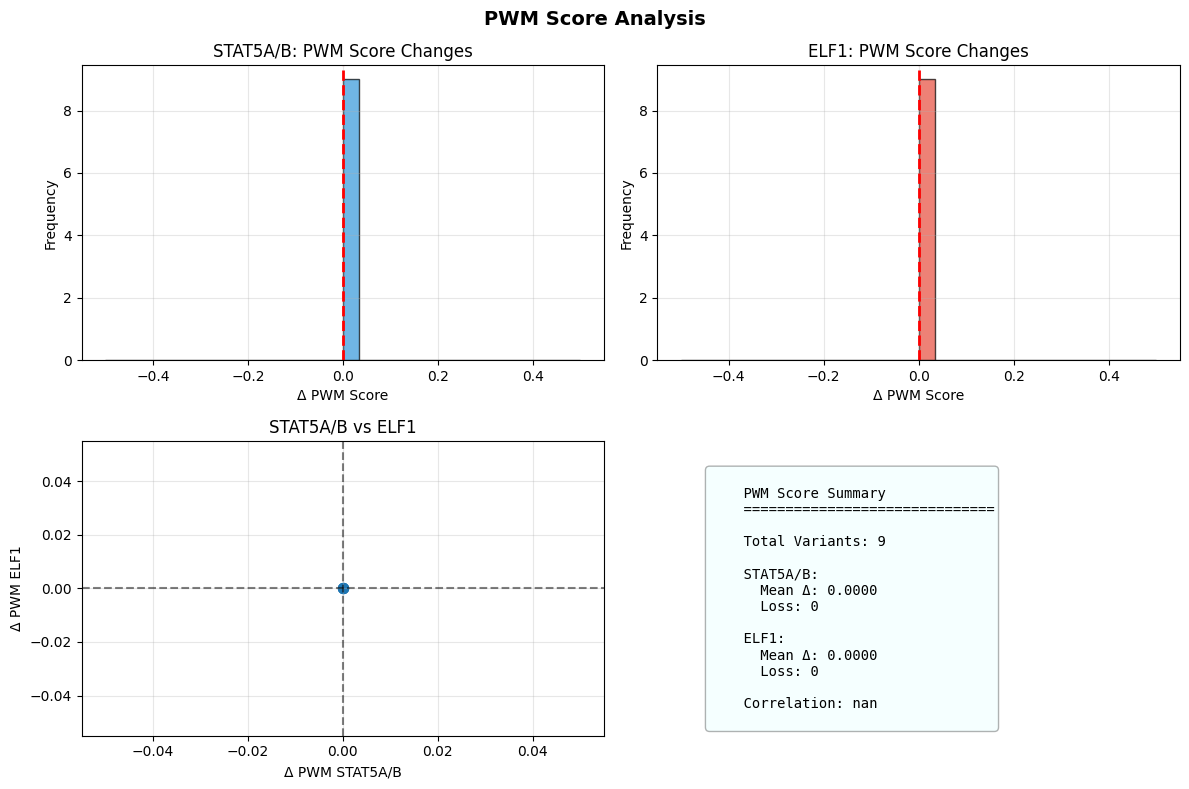

In [54]:
plotting.visualize_pwm_simple(pwm_scores_df, save_prefix='lupus_pwm')
plt.show()